# 1. Loading VELOX data

VELOX is a thermal infrared imager (640 x 512 pixels, 35.5° x 28.7° field of view) that looks down from the research aircraft HALO. A filter wheel records brightness temperatures in five channels:

| channel | wavelength |
|---|---|
| 1 | 7.70 – 12.00 µm |
| 2 | 8.65 ± 0.55 µm |
| 3 | 10.74 ± 0.39 µm |
| 5 | 11.66 ± 0.81 µm |
| 6 | 12.00 ± 0.50 µm |

The final data are one netCDF file per channel and research flight, with 1 Hz frames on a common 635 x 507 pixel grid. This notebook covers `velox_tools.config` (where the files are) and `velox_tools.campaign` (loading them by time).

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import xarray as xr

from velox_tools import campaign
from velox_tools.config import load_config

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']),
})

## Where the data are

`velox_tools.campaign` finds the files below `data_root`, the directory that holds the `HALO-AC3/` and `PERCUSION/` campaign archives. It is taken from, in this order:

1. `data_root` in a `config.yaml` in the working directory or any parent directory (so a `config.yaml` in the repository root also applies to these notebooks),
2. the environment variable `VELOX_DATA_ROOT`,
3. `/projekt_agmwend/data` or `P:/data`, whichever exists.

In [2]:
config = load_config()
print('data_root:  ', config.data_root)
print('config file:', config.config_file)

data_root:   /projekt_agmwend/data
config file: /projekt_agmwend/home_rad/Joshua/pyVELOX/config.yaml


The file layout below `data_root` is given by `campaign.CAMPAIGNS`:

In [3]:
print(campaign.CAMPAIGNS['HALO-AC3']['velox'])
print(campaign.CAMPAIGNS['PERCUSION']['velox'])

HALO-AC3/02_Flights/HALO-AC3_{flight}_HALO_{rf}/VELOX/VELOX_327kveL/Processed/to_publish/final/HALO-AC3_HALO_VELOX_BT{channel}_*_{flight}_{rf}_v3.0.nc
PERCUSION/01_Flights/PERCUSION_{flight}/VELOX/06_final_files/PERCUSION_HALO_VELOX_BT{channel}_*_{flight}.nc


The HALO-(AC)3 files are the ones published on [PANGAEA](https://doi.org/10.1594/PANGAEA.963401). A single file can also be opened directly with xarray:

In [4]:
pattern = campaign.CAMPAIGNS['HALO-AC3']['velox'].format(flight='20220320', rf='RF07', channel=3)
path = glob.glob(os.path.join(config.data_root, pattern))[0]
xr.open_dataset(path)

<xarray.Dataset> Size: 40GB
Dimensions:    (time: 31103, x: 635, y: 507)
Coordinates:
  * time       (time) datetime64[ns] 249kB 2022-03-20T07:54:08 ... 2022-03-20...
Dimensions without coordinates: x, y
Data variables:
    lat        (time) float32 124kB ...
    lon        (time) float32 124kB ...
    alt        (time) float32 124kB ...
    yaw        (time) float32 124kB ...
    vza        (x, y) float32 1MB ...
    vaa        (x, y) float32 1MB ...
    BT_2D      (time, x, y) float32 40GB ...
    BT_Center  (time) float32 124kB ...
Attributes: (12/21)
    title:                   Two-dimensional cloud-top or surface brightness ...
    research_flight_day:     20220320
    research_flight_number:  RF07
    version:                 Version v3.0 from 2023-09-11
    comment_1:               Band wavelength range: 10.74 +/- 0.39 micrometers
    comment_2:               Flight direction is towards positive y-direction...
    ...                      ...
    institution:             Leipzig University, Leipzig Institute for Meteor...
    author:                  Michael Schäfer, Sophie Rosenburg, André Ehrlich...
    history:                 2023-09-11: First version with destriping, image...
    reference:               Schäfer, M., Wolf, K., Ehrlich, A., Hallbauer, C...
    created_on:              2023-10-08
    Conventions:             "CF-1.8"

## From time to research flight

All functions in `velox_tools.campaign` take a time -- a slice, a timestamp or a date string. Campaign and research flight follow from the date:

In [5]:
print(campaign.flight('2022-03-20'))
print(campaign.flight(slice('2024-08-25T12:24', '2024-08-25T12:36')))
print(campaign.flight('2024-11-12T10:00'))

('HALO-AC3', 'RF07')
('PERCUSION', 'RF07')
('PERCUSION', 'ECVal_RF04')


In [6]:
for name, c in campaign.CAMPAIGNS.items():
    print(f"{name}: {len(c['flights'])} flights, {', '.join(c['flights'])}")

HALO-AC3: 16 flights, RF03, RF04, RF05, RF06, RF07, RF08, RF09, RF10, RF11, RF12, RF13, RF14, RF15, RF16, RF17, RF18
PERCUSION: 29 flights, RF01, RF02, RF03, RF04, RF05, RF06, RF07, RF08, RF09, RF10, RF11, RF12, RF13, RF14, RF15, RF16, RF17, RF18, RF19, RF20, RF21, RF22, RF23, ECVal_RF01, ECVal_RF02, ECVal_RF03, ECVal_RF04, ECVal_RF05, ECVal_RF06


## Brightness temperatures

`load_velox` returns all channels on the frame times of the first one, with the channel number as `band` coordinate. The data are loaded lazily, so only what you use is read from disk. The example is part of a circle flown over tropical convection during PERCUSION.

In [7]:
ds = campaign.load_velox(slice('2024-08-25T12:30:00', '2024-08-25T12:30:09'))
ds

<xarray.Dataset> Size: 64MB
Dimensions:    (band: 5, time: 10, x: 635, y: 507)
Coordinates:
  * time       (time) datetime64[ns] 80B 2024-08-25T12:30:00.286000 ... 2024-...
  * band       (band) int64 40B 1 2 3 5 6
  * x          (x) int64 5kB 0 1 2 3 4 5 6 7 ... 627 628 629 630 631 632 633 634
  * y          (y) int64 4kB 0 1 2 3 4 5 6 7 ... 499 500 501 502 503 504 505 506
Data variables:
    BT_2D      (band, time, x, y) float32 64MB dask.array<chunksize=(1, 10, 635, 507), meta=np.ndarray>
    BT_Center  (band, time) float32 200B dask.array<chunksize=(1, 10), meta=np.ndarray>
Attributes:
    campaign:         PERCUSION
    research_flight:  RF07

The flight direction is +y, and x = 0 is on the starboard side. With the x axis inverted, the frames show the scene as seen from above, with the aircraft flying up the page:

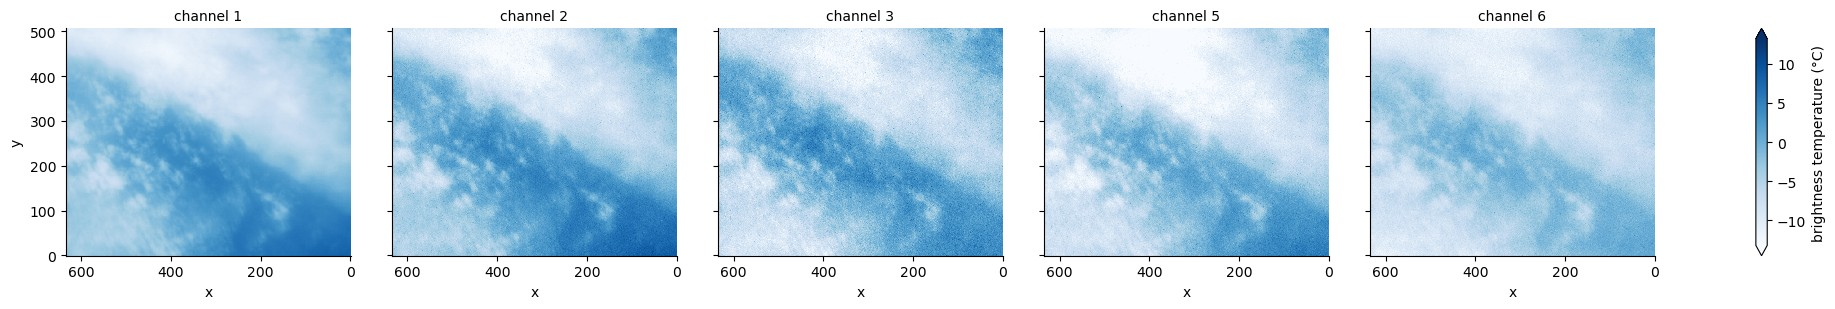

In [8]:
g = ds['BT_2D'].isel(time=0).plot.imshow(x='x', y='y', col='band', cmap='Blues', robust=True,
                                        size=3.2, aspect=635 / 507,
                                        cbar_kwargs=dict(label='brightness temperature (°C)'))
g.set_titles('channel {value}')
for ax in g.axs.flat:
    ax.invert_xaxis()
    ax.set_aspect('equal')

`BT_Center`, the mean of the central 10 x 10 pixels, gives a quick overview of a longer segment. Only `BT_Center` is read here, not the full frames.

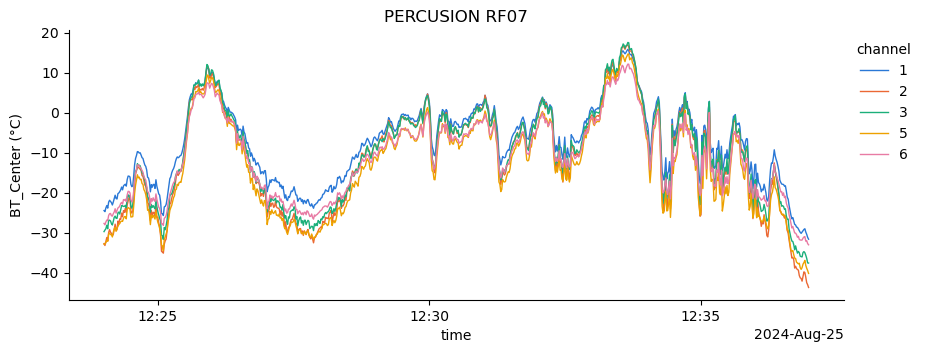

In [9]:
segment = campaign.load_velox(slice('2024-08-25T12:24', '2024-08-25T12:36'))
fig, ax = plt.subplots(figsize=(10, 3.5))
segment['BT_Center'].plot.line(x='time', hue='band', ax=ax, linewidth=1)
ax.set_ylabel('BT_Center (°C)')
ax.set_title('PERCUSION RF07')
ax.legend(title='channel', labels=segment.band.values, frameon=False, loc='upper left', bbox_to_anchor=(1, 1));

## Navigation data

`load_nav` reads the BAHAMAS navigation data (10 Hz) of the flight, with the variable names used throughout the package:

In [10]:
nav = campaign.load_nav('2024-08-25')
nav

<xarray.Dataset> Size: 15MB
Dimensions:  (time: 350340)
Coordinates:
  * time     (time) datetime64[ns] 3MB 2024-08-25T09:14:50 ... 2024-08-25T18:...
Data variables:
    lat      (time) float64 3MB 16.74 16.74 16.74 16.74 ... 16.73 16.73 16.73
    lon      (time) float64 3MB -22.95 -22.95 -22.95 ... -22.95 -22.95 -22.95
    alt      (time) float32 1MB 90.8 90.94 91.09 91.25 ... 88.81 88.73 88.64
    gs       (time) float32 1MB 80.78 80.97 81.15 81.33 ... 58.81 58.71 58.61
    hdg      (time) float32 1MB 0.3141 0.3205 0.3354 ... 0.6709 0.6375 0.5985
    roll     (time) float32 1MB -1.271 -1.21 -1.09 ... -0.171 -0.1615 -0.1311
    pitch    (time) float32 1MB 5.968 6.115 6.235 6.322 ... 1.584 1.388 1.217
Attributes: (12/19)
    title:                Quality controlled data of DLR measurment flight ad...
    aircraft:             D-ADLR
    project:              PERCUSION
    mission:              PERCUSION
    ProjectInvestigator:  Bjorn Stevens
    flightname:           adlr_20240825a
    ...                   ...
    date_last_revised:    2025-2-6
    TimeInterval:         09:14:50 - 18:58:44
    comment:               Humidity is measured with SHARC and/or HUMICAP VAI...
    platform:             HALO
    instrument:           BAHAMAS
    Variablelist:          TIME IGI_RMSX IGI_RMSY IGI_RMSZ IRS_ALT IRS_ATA IR...

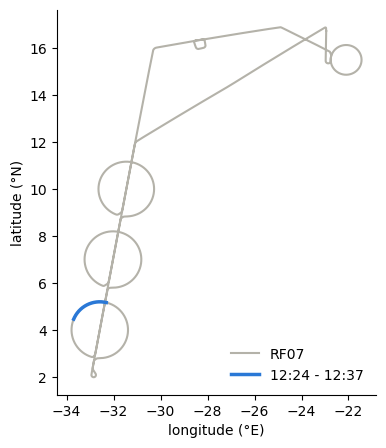

In [11]:
leg = nav.sel(time=slice('2024-08-25T12:24', '2024-08-25T12:36'))
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(nav['lon'], nav['lat'], color='#b4b2a9', linewidth=1.5, label='RF07')
ax.plot(leg['lon'], leg['lat'], color='#2a78d6', linewidth=2.5, label='12:24 - 12:37')
ax.set(xlabel='longitude (°E)', ylabel='latitude (°N)', aspect='equal')
ax.legend(frameon=False);

`interp_nav` puts the navigation data on the frame times. The heading is interpolated via sine and cosine, so it doesn't jump when crossing north.

In [12]:
nav_frames = campaign.interp_nav(nav, ds.time)
nav_frames[['alt', 'gs', 'hdg', 'roll', 'pitch']].to_dataframe().round(2)

,alt,gs,hdg,roll,pitch
time,,,,,
2024-08-25 12:30:00.286,13894.75,241.67,245.26,-2.04,2.69
2024-08-25 12:30:01.310,13894.42,241.64,245.16,-2.11,2.75
2024-08-25 12:30:02.334,13894.34,241.59,245.06,-2.10,2.79
2024-08-25 12:30:03.358,13894.49,241.54,244.96,-1.89,2.83
2024-08-25 12:30:04.382,13894.83,241.48,244.84,-1.87,2.83
2024-08-25 12:30:05.406,13895.28,241.41,244.69,-1.92,2.85
2024-08-25 12:30:06.430,13895.78,241.34,244.55,-2.03,2.84
2024-08-25 12:30:07.454,13896.25,241.27,244.40,-2.23,2.84
2024-08-25 12:30:08.478,13896.63,241.20,244.24,-2.49,2.80
